# Leading, Coincident & Lagging Macro Indicators

Business-cycle indicators are conventionally grouped by *when* they move relative to the cycle, following the Conference Board's classification:

- **Leading** — turn before the cycle (yield curve, jobless claims, building permits, new orders, consumer sentiment, manufacturing hours).
- **Coincident** — move with the cycle (payrolls, industrial production, personal income, retail sales).
- **Lagging** — confirm the cycle after the fact (unemployment duration, business loans, the prime rate, core CPI, unit labor cost).

This notebook queries 16 US indicators from FRED (all live-verified 2026-07-16) plus a deliberately thin 3-indicator Thailand panel (SET Index, GDP growth, CPI inflation — the only keyless, reasonably current sources available for this framework), and plots each US category as a normalized trend shaded by NBER recession periods so the lead/coincident/lag relationship is visible directly in the chart.

**Standalone notebook:** series are fetched directly via `FredSource`/`WorldBankSource`/`yfinance`, not through `macro_data.update()`/`catalog.yaml` — nothing here is persisted to `data/`. See `macro_cycle_indicators_catalog.csv` alongside this notebook for the full roster with tags.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from macro_data.catalog import SeriesConfig
from macro_data.sources.fred import FredSource
from macro_data.sources.worldbank import WorldBankSource

pd.set_option("display.max_rows", 25)
%matplotlib inline

In [2]:
roster = pd.read_csv("macro_cycle_indicators_catalog.csv")
roster

,id,region,source,tag,frequency,name
0,T10Y3M,US,fred,leading,daily,10Y-3M Treasury yield spread
1,ICSA,US,fred,leading,weekly,Initial jobless claims
2,PERMIT,US,fred,leading,monthly,Building permits (new private housing units au...
3,NEWORDER,US,fred,leading,monthly,Manufacturers' new orders: core capital goods ...
4,UMCSENT,US,fred,leading,monthly,U. Michigan Consumer Sentiment Index
5,AWHMAN,US,fred,leading,monthly,Average weekly hours (manufacturing)
6,PAYEMS,US,fred,coincident,monthly,Nonfarm payroll employment
7,INDPRO,US,fred,coincident,monthly,Industrial production index
8,W875RX1,US,fred,coincident,monthly,Real personal income excluding transfer receipts
9,USPHCI,US,fred,coincident,monthly,Coincident Economic Activity Index (composite)


In [3]:
FRED_SERIES = {
    "T10Y3M": ("leading", "D"),
    "ICSA": ("leading", "W"),
    "PERMIT": ("leading", "M"),
    "NEWORDER": ("leading", "M"),
    "UMCSENT": ("leading", "M"),
    "AWHMAN": ("leading", "M"),
    "PAYEMS": ("coincident", "M"),
    "INDPRO": ("coincident", "M"),
    "W875RX1": ("coincident", "M"),
    "USPHCI": ("coincident", "M"),
    "RSAFS": ("coincident", "M"),
    "UEMPMEAN": ("lagging", "M"),
    "BUSLOANS": ("lagging", "M"),
    "MPRIME": ("lagging", "M"),
    "CPILFESL": ("lagging", "M"),
    "ULCNFB": ("lagging", "Q"),
}

fred = FredSource()
us_raw = {}
us_failed = {}
for series_id, (tag, freq) in FRED_SERIES.items():
    cfg = SeriesConfig(id=series_id, source="fred", name=series_id, params={"series": series_id})
    try:
        us_raw[series_id] = fred.fetch(cfg)
    except Exception as exc:
        us_failed[series_id] = str(exc)
        print(f"failed to fetch {series_id}: {exc}")

# NBER recession indicator — used only for chart shading, not a tagged series itself
recession_cfg = SeriesConfig(id="USREC", source="fred", name="USREC", params={"series": "USREC"})
usrec = fred.fetch(recession_cfg)

print(f"fetched {len(us_raw)}/{len(FRED_SERIES)} US series" + (f"; failed: {list(us_failed)}" if us_failed else ""))

fetched 16/16 US series


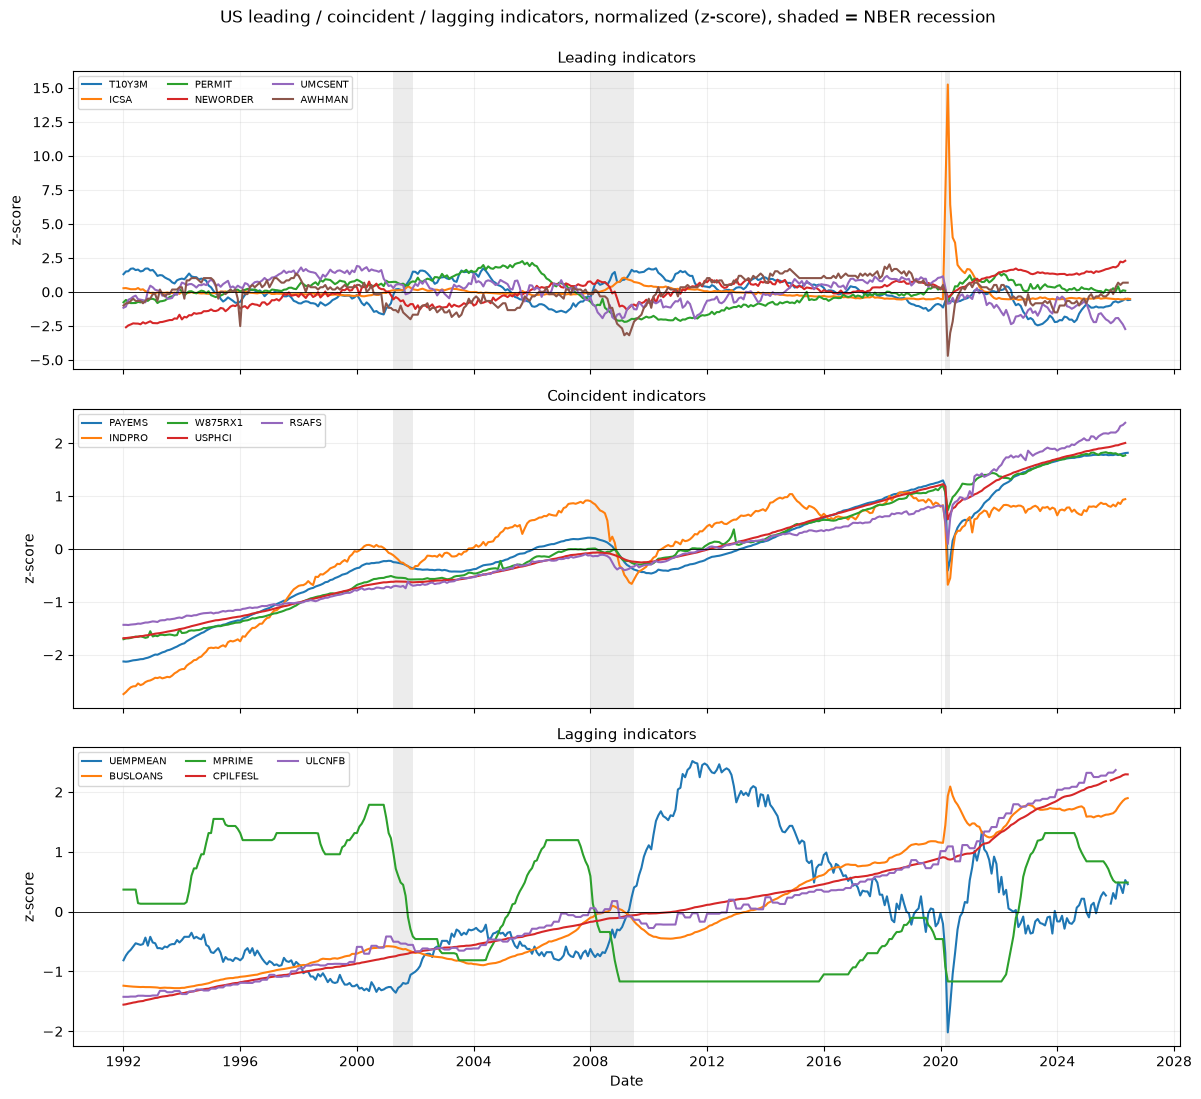

In [4]:
WINDOW_START = "1992-01-01"


def to_monthly(df, freq):
    s = df["value"]
    if freq in ("D", "W"):
        return s.resample("MS").mean()
    if freq == "Q":
        return s.resample("MS").ffill()
    return s.resample("MS").last()


us_monthly = {
    series_id: to_monthly(df, FRED_SERIES[series_id][1])
    for series_id, df in us_raw.items()
}
usrec_monthly = usrec["value"].resample("MS").max()

categories = {"leading": [], "coincident": [], "lagging": []}
for series_id, (tag, _freq) in FRED_SERIES.items():
    if series_id in us_monthly:
        categories[tag].append(series_id)

category_frames = {
    tag: pd.DataFrame({sid: us_monthly[sid] for sid in ids}).dropna(how="all")
    for tag, ids in categories.items()
}


def zscore(frame, start=WINDOW_START):
    windowed = frame.loc[start:]
    return (windowed - windowed.mean()) / windowed.std()


zscored = {tag: zscore(frame) for tag, frame in category_frames.items()}


def recession_spans(flags):
    flags = flags.dropna()
    spans = []
    span_start = None
    for date, val in flags.items():
        if val >= 0.5 and span_start is None:
            span_start = date
        elif val < 0.5 and span_start is not None:
            spans.append((span_start, date))
            span_start = None
    if span_start is not None:
        spans.append((span_start, flags.index[-1]))
    return spans


rec_spans = recession_spans(usrec_monthly.loc[WINDOW_START:])

tag_titles = {
    "leading": "Leading indicators",
    "coincident": "Coincident indicators",
    "lagging": "Lagging indicators",
}

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
for ax, tag in zip(axes, ["leading", "coincident", "lagging"]):
    frame = zscored[tag]
    for col in frame.columns:
        ax.plot(frame.index, frame[col], linewidth=1.5, label=col)
    for span_start, span_end in rec_spans:
        ax.axvspan(span_start, span_end, color="grey", alpha=0.15, linewidth=0)
    ax.set_title(tag_titles[tag], fontsize=11)
    ax.set_ylabel("z-score")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.legend(fontsize=7, ncol=3, loc="upper left")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Date")
fig.suptitle(
    "US leading / coincident / lagging indicators, normalized (z-score), shaded = NBER recession",
    y=0.995,
)
plt.tight_layout()
plt.show()

## Reading the chart

Historically, **leading** indicators such as the yield curve spread and jobless claims tend to turn several months to over a year before a recession begins. **Coincident** indicators — payrolls, industrial production — move together with the cycle, which is why they're used to date recessions after the fact. **Lagging** indicators such as unemployment duration and business loan balances typically keep deteriorating for months *after* a recession has already ended, since employers and lenders adjust slowly. The shaded bands mark NBER recession months; watch how the three panels above cross zero at different points around each band.

In [5]:
snapshot_rows = []
for series_id, (tag, freq) in FRED_SERIES.items():
    if series_id not in us_raw:
        continue
    s = us_raw[series_id]["value"]
    snapshot_rows.append(
        {
            "series": series_id,
            "tag": tag,
            "latest_value": s.iloc[-1],
            "as_of": s.index[-1].date(),
        }
    )

snapshot = pd.DataFrame(snapshot_rows).set_index("series").sort_values(["tag", "series"])
snapshot

,tag,latest_value,as_of
series,,,
INDPRO,coincident,102.6475,2026-05-01
PAYEMS,coincident,158984.0000,2026-06-01
RSAFS,coincident,763705.0000,2026-05-01
USPHCI,coincident,149.1700,2026-05-01
W875RX1,coincident,16564.1000,2026-05-01
BUSLOANS,lagging,2894.7013,2026-06-01
CPILFESL,lagging,336.0650,2026-06-01
MPRIME,lagging,6.7500,2026-06-01
UEMPMEAN,lagging,25.5000,2026-06-01
